In [11]:
import sys
import time

import pandas as pd
import numpy as np
from itertools import combinations
from shap import Explanation
import sys
import torch
import math
import random
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import math
import xgboost
import shap
import time
import itertools
from weighted_shapley import Weighted_Shapley
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)

In [12]:
x1 =np.random.normal(0, 1, size=(10000, 1)) 
x2 =0.01*np.random.normal(0, 1, size=(10000, 1)) + 0.9999*x1
#x3 = np.random.normal(0, 1, size=(10000, 1))
x3 = np.random.normal(0, 1, size=(10000, 1)) 
#x5 = 0.77* np.random.normal(0, 1, size=(10000, 1))  + 0.77 * x2 
#x6 = 0.707 * np.random.normal(0, 1, size=(10000, 1)) + 0.707 * x3
x6 = 0.5 * np.random.normal(0, 1, size=(10000, 1)) + 0.5 * x2  + 0.5 * x3
x4 = np.random.normal(0, 1, size=(10000, 1)) 
x5 = 0.57 * np.random.normal(0, 1, size=(10000, 1)) + 0.57 * x4 + 0.57 * x6
arr = np.hstack((x1, x2, x3, x4, x5, x6))
pd_data = pd.DataFrame(arr, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
pd_data = (pd_data-pd_data.mean())/pd_data.std()
X = pd_data[['x1', 'x2', 'x3', 'x4', 'x5']]
y = pd_data["x6"]
feature_num = 5

In [13]:
print(y.mean())

-4.618527782440651e-17


In [14]:
lr = LinearRegression()
lr.fit(X, y)
w = lr.coef_[0]

In [15]:
lr.coef_

array([-0.62871845,  1.08556958,  0.46437773, -0.23606907,  0.38137162])

In [16]:
import itertools
#to create the oracle:
#we create a dictionary that maps each feature to a set of sets of features that d-separate the variable from X_[n+1]
#nodes that are directly connected to X_{n+1} can not be d-separated from X_{n+1} by any set of nodes thus the set of sets is empty
#for other nodes we  need to identify all such sets
#for node X1 (for the example in the supplementary material) all subsets of variables that include X_2 d-separate it from X_[6]

oracle = {}
s = ['x3', 'x4', 'x5']
all_subsets = [subset for i in range(len(s)+1) for subset in itertools.combinations(s, i)]
def findsubsets(s, n):
    return list(itertools.combinations(s, n))
sets = {frozenset({'x2'}.union(set(s))) for s in all_subsets}
oracle['x1'] = sets

#X2 and X3 are directly connected to X6 thus the set of sets is empty
oracle['x2'] = set()
oracle['x3'] = set()

s = ['x1', 'x2', 'x3']
all_subsets = [subset for i in range(len(s)+1) for subset in itertools.combinations(s, i)]
def findsubsets(s, n):
    return list(itertools.combinations(s, n))
sets = {frozenset(set(s)) for s in all_subsets}
oracle['x4'] = sets
oracle['x5'] = set()



In [17]:
print(f'data point is {X.iloc[23]}\n and f is {lr.predict(X.iloc[23].values.reshape(1, -1))}')

data point is x1   -0.732814
x2   -0.727355
x3   -1.013126
x4    0.623060
x5    0.484550
Name: 23, dtype: float64
 and f is [-0.76162558]


In [18]:
from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, feature_num)
PaCh, sp, ch = sh.parents_children_spouses(X.iloc[23], oracle)
print(f'parents and children of x6 are {PaCh}\nand the spouses  are {sp}\nand the children are {ch}')

parents and children of x6 are ['x2', 'x3', 'x5']
and the spouses  are ['x4']
and the children are ['x5']


Given this information, we know that we should that the graphical representation entails that the nodes x5  does not have interventional influence on x6.

If we assume that the underlying structure is a tree, we can infer that x4 also does not have interventional properties.
Now, if we know the underlying skeleton of the rest of the graph we can proceed to calculate ancestor shapley values.

In [19]:
def create_ordering(ancestors, features):
    s = set(ancestors)
    non_ancestor = [x for x in features if x not in s]
    perms1 = list(itertools.permutations(ancestors))
    perms2 = list(itertools.permutations(non_ancestor))
    ancestor_compatible_perms = []
    for item1 in perms1:
        for item2 in perms2:
            #item1 is the permutation of the ancestors
            #item2 is the permutation of the other variables
            temp = item1 + item2
            ancestor_compatible_perms.append(temp)
    return tuple(non_ancestor), tuple(ancestor_compatible_perms)


ancestor_oracle = {}
feature_names = ('x1', 'x2', 'x3', 'x4', 'x5')

graph_1_ancestors = ('x1', 'x2', 'x3')
non_ancestor1, graph_1_orderings = create_ordering(graph_1_ancestors, feature_names)
graph1 = {'ancestors': graph_1_ancestors, 'non_ancestor': non_ancestor1}
ancestor_oracle['graph1'] = graph1    
   
graph_2_ancestors = ('x2', 'x3')
non_ancestor2, graph_2_orderings = create_ordering(graph_2_ancestors, feature_names)
graph2 = {'ancestors': graph_2_ancestors, 'non_ancestor': non_ancestor2}
ancestor_oracle['graph2'] = graph2

graph_3_ancestors = ( 'x2',)
non_ancestor3, graph_3_orderings = create_ordering(graph_3_ancestors, feature_names)
graph3 = {'ancestors': graph_3_ancestors, 'non_ancestor': non_ancestor3}
ancestor_oracle['graph3'] = graph3

graph_4_ancestors = ( 'x1', 'x2')
non_ancetors4, graph_4_orderings = create_ordering(graph_4_ancestors, feature_names)
graph4 = {'ancestors': graph_4_ancestors, 'non_ancestor': non_ancetors4}
ancestor_oracle['graph4'] = graph4

graph_5_ancestors = ('x3',)
non_ancestor5, graph_5_orderings = create_ordering(graph_5_ancestors, feature_names)
graph5 = {'ancestors': graph_5_ancestors, 'non_ancestor': non_ancestor5}
ancestor_oracle['graph5'] = graph5

graph_6_ancestors = tuple()
non_ancestor6, graph_6_orderings = create_ordering(graph_6_ancestors, feature_names)
graph_6 = {'ancestors': graph_6_ancestors, 'non_ancestor': non_ancestor6}
ancestor_oracle['graph6'] = graph_6

In [21]:
from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, feature_num)
b = sh.find_shapley(X.iloc[23], explanation_type="graph ancestor", ancestor_oracle=ancestor_oracle)

we have 720 orderings
phi shape is (720, 5)
 data point type is :<class 'pandas.core.series.Series'>
5


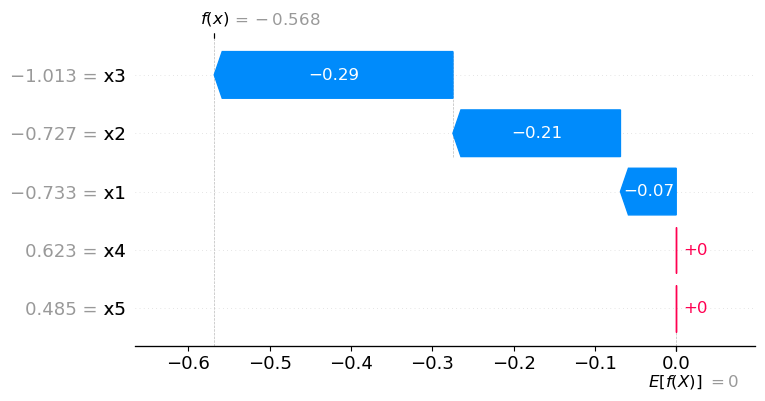

In [22]:
shap.waterfall_plot(b)

In [23]:
from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, feature_num)
c = sh.find_shapley(X.iloc[23], explanation_type="standard", sparsest_oracle=oracle)


 data point type is :<class 'pandas.core.series.Series'>
5


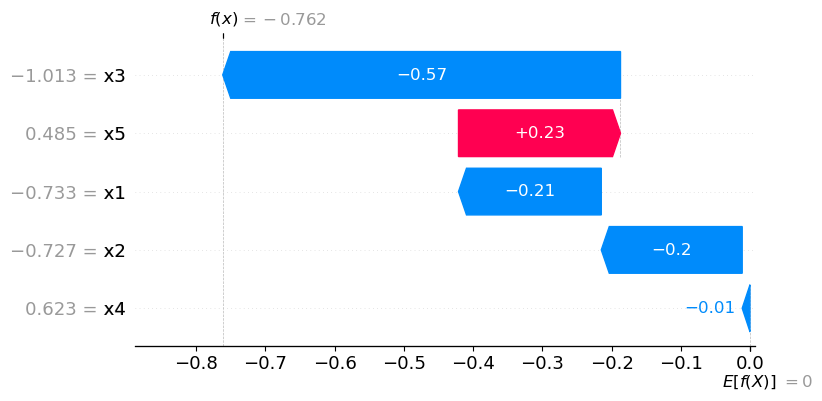

In [24]:
shap.waterfall_plot(c)

Example in the main article

In [2]:
x1 =np.random.normal(0, 1, size=(10000, 1)) 
x2 =0.01*np.random.normal(0, 1, size=(10000, 1)) + 0.9999*x1
#x3 = np.random.normal(0, 1, size=(10000, 1))
x3 = np.random.normal(0, 1, size=(10000, 1)) 
#x5 = 0.77* np.random.normal(0, 1, size=(10000, 1))  + 0.77 * x2 
#x6 = 0.707 * np.random.normal(0, 1, size=(10000, 1)) + 0.707 * x3
x6 = 0.5 * np.random.normal(0, 1, size=(10000, 1)) + 0.5 * x2  + 0.5 * x3
arr = np.hstack((x1, x2, x3, x6))
pd_data = pd.DataFrame(arr, columns=['x1', 'x2', 'x3', 'x6'])
pd_data = (pd_data-pd_data.mean())/pd_data.std()
X = pd_data[['x1', 'x2', 'x3']]
y = pd_data["x6"]
feature_num = 3

In [3]:
lr = LinearRegression()
lr.fit(X, y)
w = lr.coef_[0]

In [4]:
def create_ordering(ancestors, features):
    s = set(ancestors)
    non_ancestor = [x for x in features if x not in s]
    perms1 = list(itertools.permutations(ancestors))
    perms2 = list(itertools.permutations(non_ancestor))
    ancestor_compatible_perms = []
    for item1 in perms1:
        for item2 in perms2:
            #item1 is the permutation of the ancestors
            #item2 is the permutation of the other variables
            temp = item1 + item2
            ancestor_compatible_perms.append(temp)
    return tuple(non_ancestor), tuple(ancestor_compatible_perms)


ancestor_oracle = {}
feature_names = ('x1', 'x2', 'x3')

graph_1_ancestors = ('x1', 'x2', 'x3')
non_ancestor1, graph_1_orderings = create_ordering(graph_1_ancestors, feature_names)
graph1 = {'ancestors': graph_1_ancestors, 'non_ancestor': non_ancestor1}
ancestor_oracle['graph1'] = graph1    
   
graph_2_ancestors = ('x2', 'x3')
non_ancestor2, graph_2_orderings = create_ordering(graph_2_ancestors, feature_names)
graph2 = {'ancestors': graph_2_ancestors, 'non_ancestor': non_ancestor2}
ancestor_oracle['graph2'] = graph2


In [5]:
print(f'data point is {X.iloc[23]}\n and f is {lr.predict(X.iloc[23].values.reshape(1, -1))}')

data point is x1   -0.732814
x2   -0.727355
x3   -1.013126
Name: 23, dtype: float64
 and f is [-0.99563623]


In [6]:
from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, feature_num)
#a = sh.find_shapley(X.iloc[23], explanation_type="ancestor", ancestor_oracle=ancestor2)
b = sh.find_shapley(X.iloc[23], explanation_type="graph ancestor", ancestor_oracle=ancestor_oracle)

we have 12 orderings
phi shape is (12, 3)
 data point type is :<class 'pandas.core.series.Series'>
3


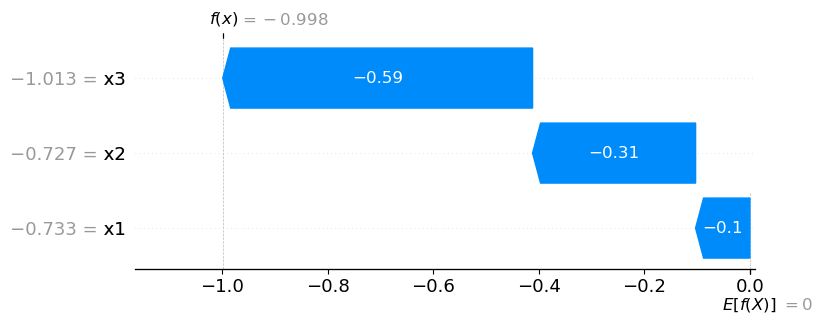

In [7]:
shap.waterfall_plot(b)

In [9]:
from weighted_shapley import Weighted_Shapley
sh = Weighted_Shapley(X, y, lr, feature_num)
c = sh.find_shapley(X.iloc[23], explanation_type="standard")

 data point type is :<class 'pandas.core.series.Series'>
3


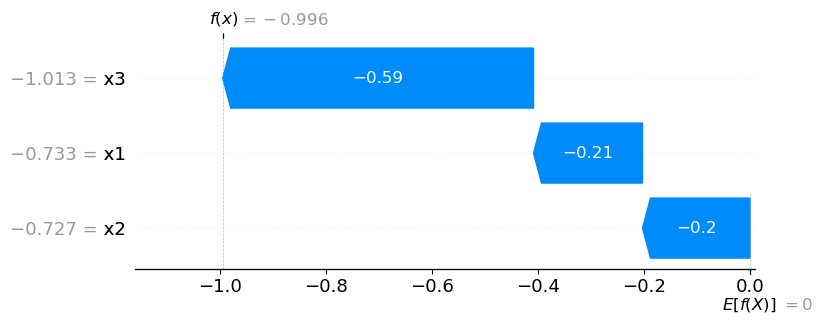

In [10]:
shap.waterfall_plot(c)